In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator
from typing import Callable
import pandas as pd
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_absolute_percentage_error, r2_score, root_mean_squared_error

import bambi as bmb
import arviz as az
from scipy.stats import norm

# custom 
from utils import ts_parents, all_formulas_from_structures, train_regime_models_bayesian, classify_regime_bayesian, sliding_window_regime_prediction

In [2]:
# data with estimate regime from rpcmci and true regime for test data
data = pd.read_csv("data/final_covid_data.csv", parse_dates=["date"], index_col=["date"])

In [4]:
data.columns = [f"X{i}" for i in range(len(data.columns))]
data.rename(columns={"X9": "regime"}, inplace=True)

In [5]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    #Regime 0
    0 : {
        "X0": [(0, -1)]
    },
    # Regime 1
    1: {
        "X0": [(0, -1),(7,-1),(6,-1)]
    }
}

In [6]:
#-- prepare training data
train = data[:200]
#-- filter training data by estimated regime
train1 = train[train['regime'] == 1].drop(columns=['regime'])
train0 = train[train['regime'] == 0].drop(columns=['regime'])
train1_features = ts_parents(train1, causal_structures[1])
train0_features = ts_parents(train0, causal_structures[0])
X_train = {0:train0_features,1:train1_features} # dataset for each regime

In [7]:
all_formulas = all_formulas_from_structures(causal_structures)

In [8]:
all_formulas

{0: {'X0': 'X0 ~ X0_lag1'}, 1: {'X0': 'X0 ~ X0_lag1 + X7_lag1 + X6_lag1'}}

In [9]:
bayesian_models = train_regime_models_bayesian(X=X_train, 
                                               all_formulas=all_formulas)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X0_sigma, Intercept, X0_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 76 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X0_sigma, Intercept, X0_lag1, X7_lag1, X6_lag1]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 99 seconds.


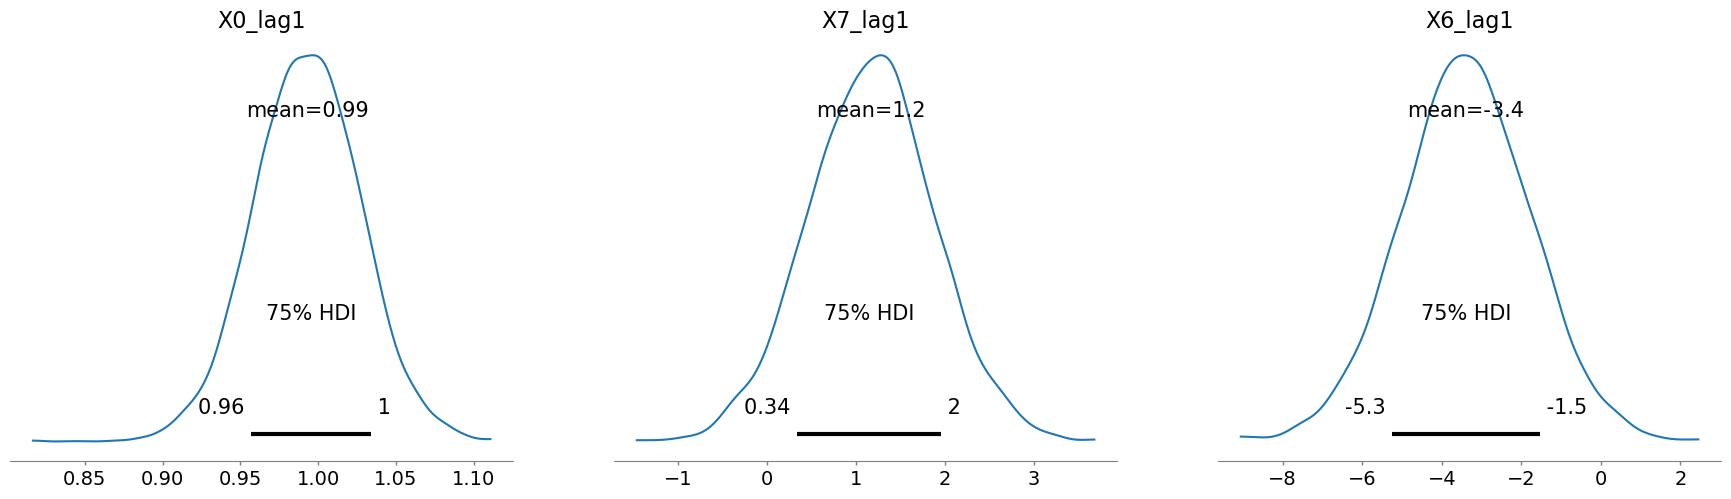

In [10]:
az.plot_posterior(bayesian_models[1]["X0"]["idata"], var_names=['X0_lag1','X7_lag1','X6_lag1'], hdi_prob=.75);

In [ ]:
test = data.iloc[180:250].copy()

test_data = test.drop(columns=['regime'])

test0 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[0]) 
test1 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[1]) 

X_test = {0:test0,1:test1} # test dataset for each regime

In [25]:
regime_prediction, errors = classify_regime_bayesian(
    X_test=X_test, 
    all_formulas=all_formulas, 
    bayesian_models=bayesian_models,
    causal_structures=causal_structures
)

In [ ]:
# classify regime with a sliding window of the last w errors 
w = 20
window_preds = sliding_window_regime_prediction(errors, window_size=w)

In [27]:
len(window_preds)

50

In [28]:
window_preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [ ]:
# add the classified regimes to dataset (instead of the true labels) for test data
test_data =  data[498:].copy()
test_data['regime'][2:] = window_preds

# Forecasting

## CaReBayes (Causal Regime Bayesian Forecasting)

In [60]:
causal_structures

{1: {'X0': [(0, -1), (7, -1), (6, -1)]}}

In [113]:
test1 = ts_parents(test_data, causal_structures[1])

test1_features= test1[test1['regime'] == 1].drop(columns=['regime'])

In [115]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[1]["X0"]["model"]
idata = bayesian_models[1]["X0"]["idata"]


preds1 = model.predict(idata=idata, data=test1_features, kind="response", inplace=False)
preds1 = preds1.posterior_predictive["X0"]  

mean_pred = preds1.mean(dim=("chain", "draw")).values
lower = preds1.quantile(0.025, dim=("chain", "draw")).values
upper = preds1.quantile(0.975, dim=("chain", "draw")).values

y_test = test1_features["X0"][0:]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.8353062347176199
MAE: 98.68795932755343
RMSE: 117.74315874385877
MAPE: 0.11011374286443944


# Benchmarks

In [230]:
# linear regression
#-- prepare training data
train = data[:500]
train = ts_parents(train, causal_structures[1])
test = data[499:]
test = ts_parents(test, causal_structures[1])

In [232]:
def smape_metric(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return 100 * np.mean(numerator / np.clip(denominator, a_min=1e-8, a_max=None))

# VAR Benchmark Model

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR

# 1) Load your full multivariate series, assumed to have columns X0, X1, X2, X3, X4:
df = pd.read_csv("final_covid_data.csv", parse_dates=["date"], index_col=["date"])
df.drop(columns=['regimes'], inplace=True)
df.columns = [f"X{i}" for i in range(len(df.columns))]

train = df[:200]
test = df[201:250]


# Fit VAR(1) on training data
model = VAR(train, freq='D')
res = model.fit(maxlags=1)

# One-step-ahead forecasts on test range
lag_order = res.k_ar
history = train.values.copy()
one_step_preds = []

for obs in test.values:
    # Forecast one step using last lag_order observations
    last_obs = history[-lag_order:]
    yhat = res.forecast(y=last_obs, steps=1)
    # Extract X0 prediction
    one_step_preds.append(yhat[0, 0])
    # Append the actual observation to history for next forecast
    history = np.vstack([history, obs])

# Convert forecasts to Series aligned with test index
forecast_series = pd.Series(one_step_preds, index=test.index)



In [106]:
y_test = test['X0']
y_pred = forecast_series


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)


# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


R-squared (R2): 0.7516779010049925
MAE: 115.86286796945838
RMSE: 144.5788575234349
MAPE: 0.12070356457953846


# Regime-Switching VAR model

In [ ]:
# 1) Load your full multivariate series, assumed to have columns X0, X1, X2, X3, X4:
df = pd.read_csv("data/final_covid_data.csv", parse_dates=["date"], index_col=["date"])
df.drop(columns=['regimes'], inplace=True)
df.columns = [f"X{i}" for i in range(len(df.columns))]


n_vars = len(df.columns)

# 2) Build lag-1 features for all 5 series:
for j in range(n_vars):
    df[f'X{j}_lag1'] = df[f'X{j}'].shift(1)
df = df.dropna().reset_index(drop=True)

train = df[:200]
test = df[200:250]

# 4) Prepare endog & exog
y_train   = train['X0']                              # target is X0
exog_cols = [f'X{j}_lag1' for j in range(n_vars)]         # lags of X0…X9
exog_train = train[exog_cols]

# 5) Fit a 2-regime switching regression with all lagged predictors
model = MarkovRegression(
    endog=y_train,
    k_regimes=2,
    exog=exog_train,
    trend='c',
    switching_trend=True,
    switching_exog=True,
    switching_variance=True,
)
res = model.fit(method='nm', maxiter=5000, disp=False)

# 6) Extract parameters
p00, p10 = res.params['p[0->0]'], res.params['p[1->0]']
P = np.array([[p00, 1-p00],
              [p10, 1-p10]])
intercepts = np.array([res.params['const[0]'], res.params['const[1]']])
# map exog names: x1→X0_lag1, x2→X1_lag1, …, x5→X4_lag1
betas = np.vstack([
    [res.params[f'x{k+1}[0]'], res.params[f'x{k+1}[1]']]
    for k in range(n_vars)
]).T 
sigmas = np.sqrt([res.params['sigma2[0]'], res.params['sigma2[1]']])

one_step_mean = []
one_step_std = []

pi = res.filtered_marginal_probabilities.iloc[-1].values  # last filtered π

for _, row in test.iterrows():
    # propagate regime mix
    pi_pred = pi.dot(P)

    # regime-specific means: intercept + Σ β_j · Xj_lag1
    lag_vals = np.array([row[c] for c in exog_cols])
    mus = intercepts + (betas * lag_vals).sum(axis=1)

    # weighted forecast mean
    y_hat = pi_pred.dot(mus)

    # predictive variance:
    var_hat = pi_pred.dot(sigmas**2 + (mus - y_hat)**2)

    one_step_mean.append(y_hat)
    one_step_std.append(np.sqrt(var_hat))

    # update π with actual observation
    likelihoods = norm.pdf(row['X0'], loc=mus, scale=sigmas)
    pi = pi_pred * likelihoods
    pi /= pi.sum()
one_step_mean = np.array(one_step_mean)
one_step_std = np.array(one_step_std)

time_axis = df.index[201:250]

In [13]:
y_test = test['X0']
y_pred = one_step_mean


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)


# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.7086402290855381
MAE: 125.91435575777055
RMSE: 160.01955616841028
MAPE: 0.1259609617612963
